<a href="https://colab.research.google.com/github/fidelibus2148915-svg/Progetto_IA/blob/main/Progetto_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset_path="/content/drive/MyDrive/Progetto_IA/Myocardial infarction complications Database.csv"
df=pd.read_csv(dataset_path)
df.head()

,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
0,1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,1,0,0,0
4,5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0


Descrizione del dataset

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Columns: 124 entries, ID to LET_IS
dtypes: float64(110), int64(14)
memory usage: 1.6 MB


,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
count,1700.000000,1692.000000,1700.000000,1696.000000,1594.000000,1627.000000,1649.000000,72.00000,1691.000000,1692.000000,...,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000
mean,850.500000,61.856974,0.626471,0.554835,2.316186,1.205286,1.160703,0.37500,1.393258,0.033688,...,0.024706,0.041765,0.033529,0.093529,0.031765,0.044118,0.231765,0.093529,0.087059,0.477059
std,490.892045,11.259936,0.483883,0.836801,2.440586,1.040814,0.801400,0.48752,1.088803,0.180478,...,0.155273,0.200110,0.180067,0.291259,0.175425,0.205417,0.422084,0.291259,0.282004,1.381818
min,1.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,425.750000,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,850.500000,63.000000,1.000000,0.000000,1.000000,2.000000,1.000000,0.00000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1275.250000,70.000000,1.000000,1.000000,5.000000,2.000000,2.000000,1.00000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1700.000000,92.000000,1.000000,3.000000,6.000000,4.000000,2.000000,1.00000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [ ]:
#osserviamo che LET_IS è una variabile discreta multiclasse
df['LET_IS'].value_counts(normalize=True)*100

,proportion
LET_IS,
0,84.058824
1,6.470588
3,3.176471
7,1.588235
6,1.588235
4,1.352941
2,1.058824
5,0.705882


In [ ]:
#trasformazione della variabile LET_IS in target binario
df['outcome']=(df['LET_IS']!=0).astype(int)

In [ ]:
#verifica di eventuali valori mancanti della variabile target
df["LET_IS"].isna().mean()*100


np.float64(0.0)

In [ ]:
#sbilanciamento: 0 classe dei pazienti sopravvissuti e 1 classe dei pazienti deceduti
df['outcome'].value_counts()
df['outcome'].value_counts(normalize=True)*100

,proportion
outcome,
0,84.058824
1,15.941176


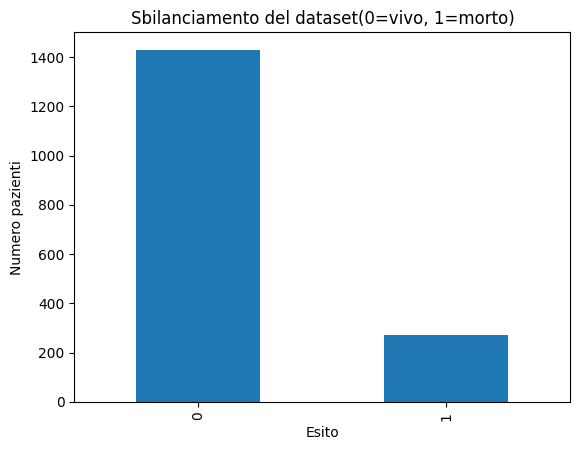

In [ ]:
#grafico dello sbilanciamento
df['outcome'].value_counts().plot(kind='bar')
plt.title('Sbilanciamento del dataset(0=vivo, 1=morto)')
plt.xlabel('Esito')
plt.ylabel('Numero pazienti')
plt.show()

Analisi esplorativa dei dati

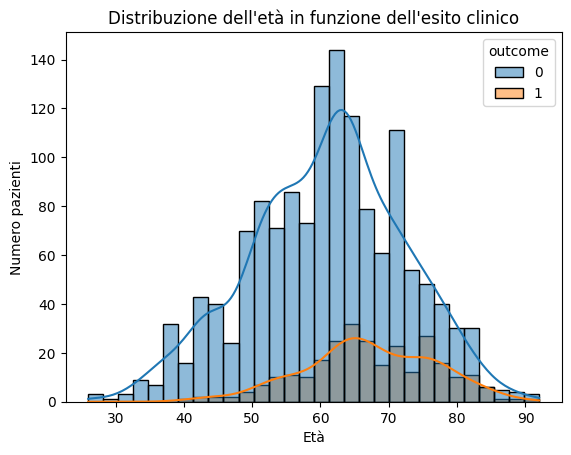

In [ ]:
#distribuzione dell'età per classe
sns.histplot(data=df,x='AGE',hue='outcome',bins=30,kde=True)
plt.title("Distribuzione dell'età in funzione dell'esito clinico")
plt.xlabel("Età")
plt.ylabel("Numero pazienti")
plt.show()

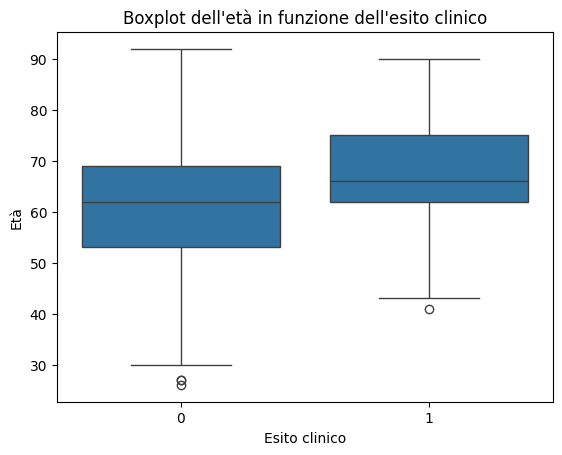

In [ ]:
#relazione con il target: età vs esito (relazione numerica)
sns.boxplot(x='outcome',y='AGE',data=df)
plt.title("Boxplot dell'età in funzione dell'esito clinico")
plt.xlabel("Esito clinico")
plt.ylabel("Età")
plt.show()

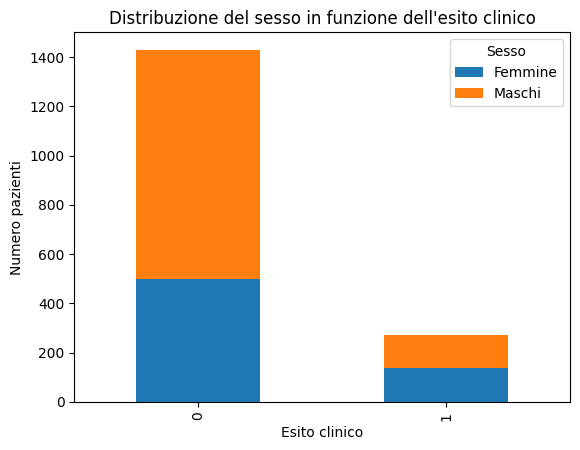

In [ ]:
#relazione con il target (relazione categorica)
pd.crosstab(df['outcome'],df['SEX']).plot(kind='bar',stacked=True)
plt.title("Distribuzione del sesso in funzione dell'esito clinico")
plt.xlabel("Esito clinico")
plt.ylabel("Numero pazienti")
plt.legend(title='Sesso',labels=['Femmine','Maschi'])
plt.show()

In [ ]:
#correlazione con il target
corr=df.corr()['outcome'].sort_values(ascending=False)
corr.head(10)

,outcome
outcome,1.000000
LET_IS,0.793013
ID,0.632734
RAZRIV,0.415923
K_SH_POST,0.355344
ZSN_A,0.216575
NITR_S,0.211606
AGE,0.203677
L_BLOOD,0.172965
STENOK_AN,0.166914


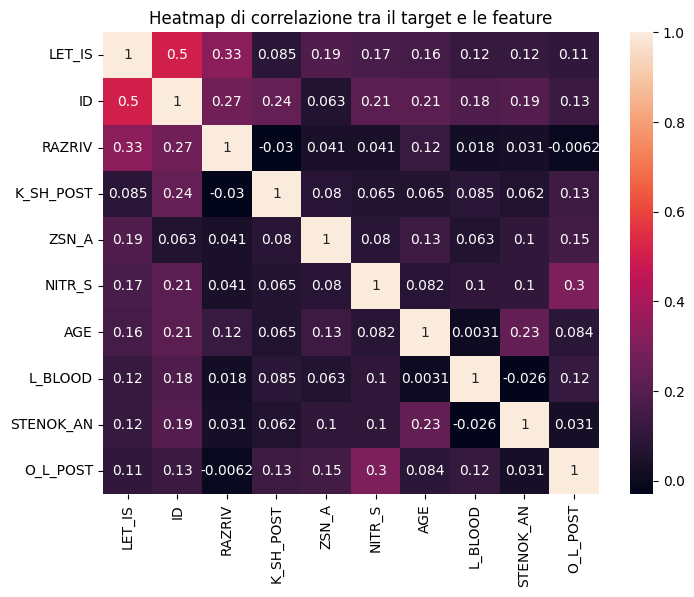

In [ ]:
#heatmap delle top correlate
top_features=corr.index[1:11]
plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr(),annot=True)
plt.title("Heatmap di correlazione tra il target e le feature")
plt.show()

Totale dati mancanti: 15974


<Axes: >

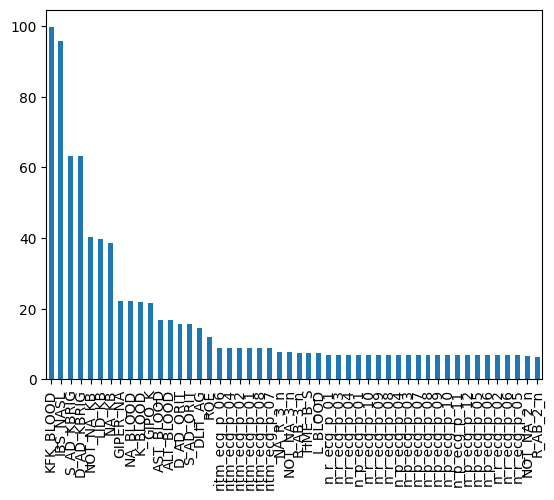

In [ ]:
#ricerca di eventuali valori mancanti nel dataset
total_missing=df.isna().sum().sum()
missing_perc=df.isna().mean()*100
print("Totale dati mancanti:",total_missing)
missing_gen=missing_perc.sort_values(ascending=False)
missing_gen.head(50)
top_missing = missing_gen.head(50)
top_missing.plot(kind='bar')

In [ ]:
#tabella che restituisce i valori mancanti per ogni colonna e la percentuale che rappresentano
missing_count=df.isna().sum()
missing_table=pd.DataFrame({
    'colonna':df.columns,
    'missing_count':missing_count.values,
    'missing_perc':(missing_count/len(df)*100)
}).sort_values('missing_perc',ascending=False).reset_index(drop=True)
#colonne che hanno almeno un valore mancante
cols_with_missing=missing_table[missing_table['missing_count']>0]
cols_with_missing

,colonna,missing_count,missing_perc
0,KFK_BLOOD,1696,99.764706
1,IBS_NASL,1628,95.764706
2,S_AD_KBRIG,1076,63.294118
3,D_AD_KBRIG,1076,63.294118
4,NOT_NA_KB,686,40.352941
...,...,...,...
105,zab_leg_01,7,0.411765
106,zab_leg_02,7,0.411765
107,NA_R_1_n,5,0.294118
108,INF_ANAM,4,0.235294


In [ ]:
print("Numero colonne con missing:",len(cols_with_missing))

Numero colonne con missing: 110


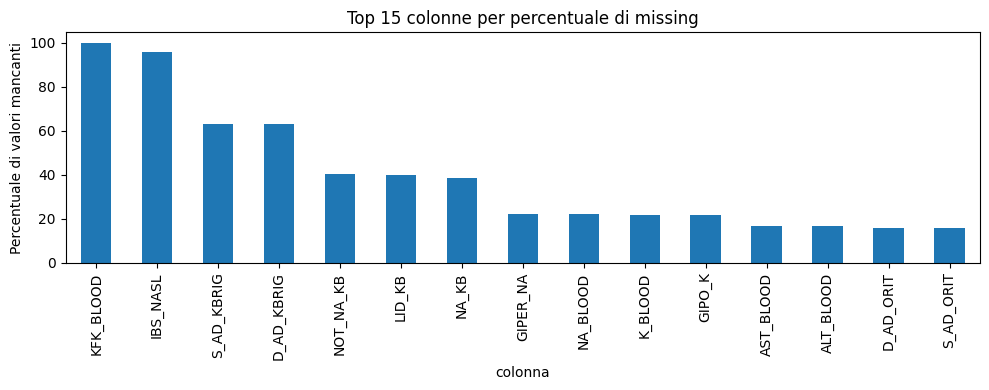

In [ ]:
#visualizzazione top 15 colonne con più missing
top_missing=cols_with_missing.head(15).set_index('colonna')['missing_perc']
plt.figure(figsize=(10,4))
top_missing.plot(kind='bar')
plt.ylabel("Percentuale di valori mancanti")
plt.title("Top 15 colonne per percentuale di missing")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Preprocessing

In [ ]:
#fissiamo una soglia del 40% per individuare le colonne con il maggior numero di valori mancanti e quindi candidate all'esclusione
to_drop=cols_with_missing[cols_with_missing['missing_perc']>40]['colonna'].tolist()
print("Colonne con >40 di valori mancanti:",len(to_drop))
print(to_drop)

Colonne con >40 di valori mancanti: 5
['KFK_BLOOD', 'IBS_NASL', 'S_AD_KBRIG', 'D_AD_KBRIG', 'NOT_NA_KB']


In [ ]:
#esclusione delle colonne che superano la soglia del 40%
df=df.drop(columns=to_drop)
print("Nuova shape del dataset:",df.shape)

Nuova shape del dataset: (1700, 120)


In [ ]:
#imputazione tramite mediana delle variabili (tutte numeriche) con valore di missing inferiore alla soglia
num_cols=df.columns
num_with_missing=[c for c in num_cols if df[c].isna().sum()>0]

for c in num_with_missing:
    df[c]=df[c].fillna(df[c].median())

In [ ]:
#verifichiamo che il numero dei valori mancanti sia effettivamente pari a 0
df.isna().sum().sum()

np.int64(0)

In [ ]:
#tutte le variabili risultano già codificate in formato numerico, pertanto non è stato necessario applicare tecniche di encoding
numeric_cols=df.select_dtypes(include=np.number).columns
len(numeric_cols)

120

In [ ]:
from sklearn.preprocessing import StandardScaler
#poiché le variabili presentano scale molto diverse, è stata applicata una standardizzazione (media 0, deviazione standard 1) tramite StandardScaler.
X=df.drop(columns=['ID','LET_IS','outcome'],axis=1)
y=df['outcome']
print(X.shape, y.shape)

(1700, 117) (1700,)


In [ ]:
from sklearn.model_selection import train_test_split
#suddivisione del dataset in training set e test set, tenendo conto del forte sbilanciamento
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#poiché le variabili presentano scale molto diverse, è stata applicata una standardizzazione (media zero e deviazione standard unitaria). La procedura di scaling è stata eseguita esclusivamente sul training set e successivamente applicata al test set, al fine di evitare fenomeni di data leakage.
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Modello

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
log_reg = LogisticRegression(max_iter=1000)

In [ ]:
#addestramento del modello
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#predizione del modello
y_pred=log_reg.predict(X_test_scaled)
y_prob=log_reg.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#valutazione dapprima attraverso la matrice di confusione
cm=confusion_matrix(y_test, y_pred)
print("Matrice di confusione:")
print(cm)

Matrice di confusione:
[[267  19]
 [ 23  31]]


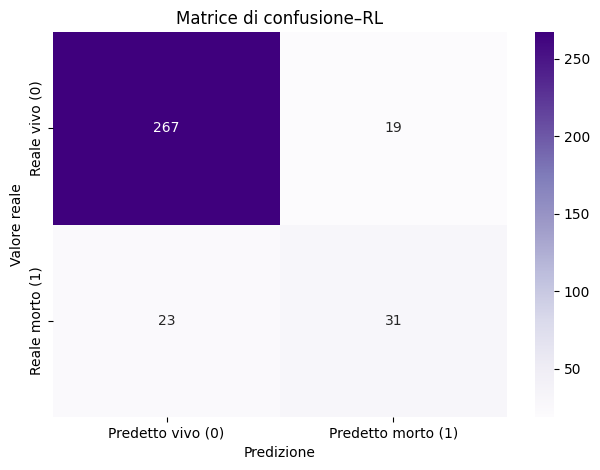

In [ ]:
#rappresentazione grafica della matrice di confusione
plt.figure()
sns.heatmap(cm,annot=True,fmt='d',cmap='Purples', xticklabels=['Predetto vivo (0)','Predetto morto (1)'],yticklabels=['Reale vivo (0)','Reale morto (1)'])
plt.xlabel("Predizione")
plt.ylabel("Valore reale")
plt.title("Matrice di confusione–RL")
plt.tight_layout()
plt.show()

In [ ]:
#precision, recall, f1-score e accuracy
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93       286
           1       0.62      0.57      0.60        54

    accuracy                           0.88       340
   macro avg       0.77      0.75      0.76       340
weighted avg       0.87      0.88      0.87       340



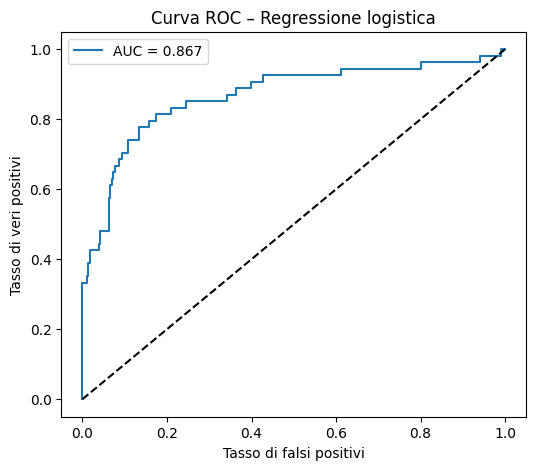

In [ ]:
#curva ROC-AUC della regressione logistica
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasso di falsi positivi')
plt.ylabel('Tasso di veri positivi')
plt.title('Curva ROC – Regressione logistica')
plt.legend()
plt.show()

In [ ]:
#abbassiamo la soglia decisionale per aumentare la recall
threshold=0.2
y_pred_new=(y_prob>=threshold).astype(int)

In [ ]:
#calcoliamo la nuova confusion matrix con soglia fissata a 0.2
cm_new=confusion_matrix(y_test, y_pred_new)
print("Matrice di confusione:")
print(cm_new)

Matrice di confusione:
[[248  38]
 [ 14  40]]


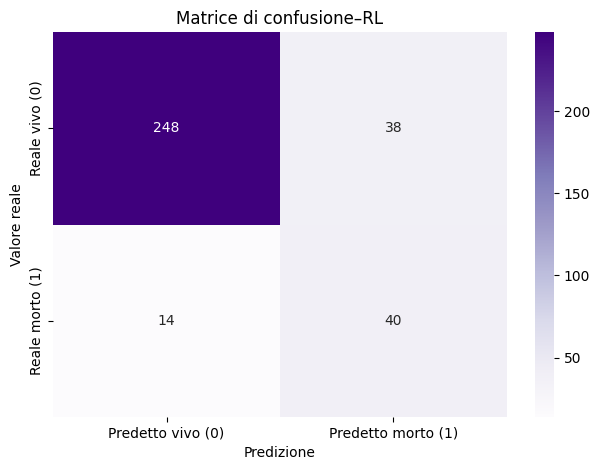

In [ ]:
plt.figure()
sns.heatmap(cm_new,annot=True,fmt='d',cmap='Purples', xticklabels=['Predetto vivo (0)','Predetto morto (1)'],yticklabels=['Reale vivo (0)','Reale morto (1)'])

plt.xlabel("Predizione")
plt.ylabel("Valore reale")
plt.title("Matrice di confusione–RL")
plt.tight_layout()
plt.show()

In [ ]:
#recall con soglia pari a 0.2
print(classification_report(y_test,y_pred_new))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91       286
           1       0.51      0.74      0.61        54

    accuracy                           0.85       340
   macro avg       0.73      0.80      0.76       340
weighted avg       0.88      0.85      0.86       340



In [ ]:
#modello LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
lda=LinearDiscriminantAnalysis()
lda.fit(X_train_scaled,y_train)

LinearDiscriminantAnalysis()

In [ ]:
y_pred_lda=lda.predict(X_test_scaled)
y_prob_lda=lda.predict_proba(X_test_scaled)

In [ ]:
cm_LDA=confusion_matrix(y_test,y_pred_lda)
print("Matrice di confusione LDA:")
print(cm_LDA)

Matrice di confusione LDA:
[[280   6]
 [ 31  23]]


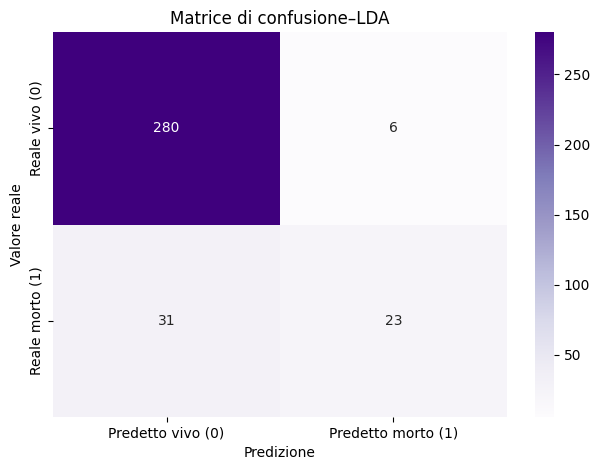

In [ ]:
plt.figure()
sns.heatmap(cm_LDA,annot=True,fmt='d',cmap='Purples', xticklabels=['Predetto vivo (0)','Predetto morto (1)'],yticklabels=['Reale vivo (0)','Reale morto (1)'])

plt.xlabel("Predizione")
plt.ylabel("Valore reale")
plt.title("Matrice di confusione–LDA")
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test,y_pred_lda)) #precision, recall, f1-score

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       286
           1       0.79      0.43      0.55        54

    accuracy                           0.89       340
   macro avg       0.85      0.70      0.75       340
weighted avg       0.88      0.89      0.88       340



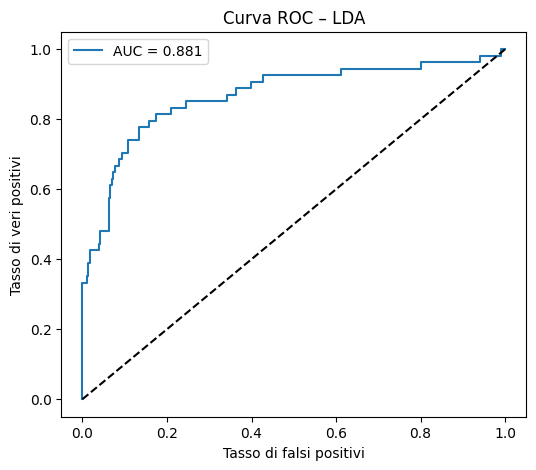

In [ ]:
#curva ROC-AUC di LDA
y_prob_lda = lda.predict_proba(X_test_scaled)[:, 1]
fpr_lda, tpr_lda, thresholds=roc_curve(y_test, y_prob_lda)
roc_auc_lda=roc_auc_score(y_test, y_prob_lda)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_lda:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasso di falsi positivi')
plt.ylabel('Tasso di veri positivi')
plt.title('Curva ROC – LDA')
plt.legend()
plt.show()

Confronto tra Regressione logistica e LDA

In [ ]:
#confronto delle matrici di confusiione dei due modelli
cm_new=confusion_matrix(y_test, y_pred_new)
cm_lda=confusion_matrix(y_test, y_pred_lda)

print("Confusion Matrix - Regressione Logistica (soglia 0.2):")
print(cm_new)

print("Confusion Matrix - LDA:")
print(cm_lda)

Confusion Matrix - Regressione Logistica (soglia 0.2):
[[248  38]
 [ 14  40]]
Confusion Matrix - LDA:
[[280   6]
 [ 31  23]]


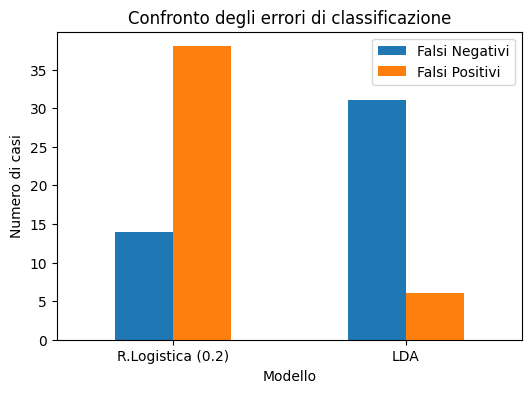

In [ ]:
#confronto degli errori di classificazione
errors=pd.DataFrame({
    'Modello':['R.Logistica (0.2)','LDA'],
    'Falsi Negativi':[cm_new[1,0],cm_lda[1,0]],
    'Falsi Positivi':[cm_new[0,1],cm_lda[0,1]]
}).set_index('Modello')

errors.plot(kind='bar', figsize=(6,4))
plt.title('Confronto degli errori di classificazione')
plt.ylabel('Numero di casi')
plt.xticks(rotation=0)
plt.show()

In [ ]:
#confronto delle metriche di valutazione (accuracy non rilevante clinicamente)
report_lr=classification_report(
    y_test, y_pred_new,
    output_dict=True
)
report_lda=classification_report(
    y_test, y_pred_lda,
    output_dict=True
)
compare_metrics=pd.DataFrame({
    'Regressione Logistica':report_lr['1'],
    'LDA':report_lda['1']
}).T[['precision', 'recall', 'f1-score']]
compare_metrics

,precision,recall,f1-score
Regressione Logistica,0.512821,0.740741,0.606061
LDA,0.793103,0.425926,0.554217


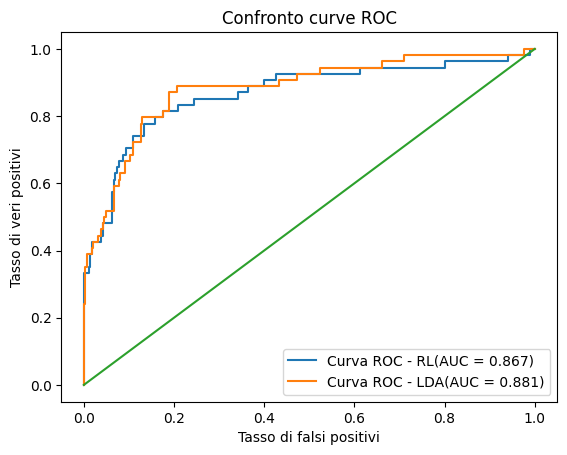

In [ ]:
#confronto grafico tra ROC di RL e ROC di LDA
plt.figure()

plt.plot(fpr,tpr,label=f"Curva ROC - RL(AUC = {roc_auc:.3f})")
plt.plot(fpr_lda,tpr_lda,label=f"Curva ROC - LDA(AUC = {roc_auc_lda:.3f})")
plt.plot([0,1],[0,1])

plt.xlabel("Tasso di falsi positivi")
plt.ylabel("Tasso di veri positivi")
plt.title("Confronto curve ROC")
plt.legend()
plt.show()